### Compare CH parameters

Explores how the CH parameters used by the SR model relate to each other, across solar cycle phases:
1. **$A_{CH}$ vs $P_{CH}$** — the two quantities that make up the SR-derived formula's acceleration term ($\sqrt{A_{CH60,t-4d} \times P_{CH30,t-4d}}$)
2. **$P_{CH}$ at 193 Å vs 211 Å** — how the same brightness parameter compares across the two EUV channels used in this study
3. **Predicted vs observed speed** — a quick sanity check using the published formula's fixed coefficients

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

V0 = 372.1075472  # calibrated slow-wind background speed (see CLAUDE.md / paper)

PHASES = ["rising", "maximum", "declining", "minimum"]
REQUIRED_COLS = [
    "A_CH60_193", "P_CH30_193", "P_CH30_211",
    "A_CH60_193_lag4", "P_CH30_211_lag4", "speed", "speed_p27",
]

dfs = {}
for phase in PHASES:
    csv_path = os.path.abspath(f"../data/processed/SR_training_{phase}.csv")
    df = pd.read_csv(csv_path, parse_dates=["datetime"])
    dfs[phase.capitalize()] = df.dropna(subset=REQUIRED_COLS)

# "entire" is not committed to git (206MB, exceeds GitHub's limit) but is the exact
# row-wise union of the four phase files above, so we reconstruct it here instead.
dfs["Entire"] = pd.concat(dfs.values(), ignore_index=True).sort_values("datetime")

PHASE_GRID = [
    ("Rising",    (0, 0)), ("Maximum",   (0, 1)), ("Declining", (0, 2)),
    ("Minimum",   (1, 0)), ("Entire",    (1, 1)),
]


def _values(df, col_or_fn):
    """col_or_fn is either a column name (str) or a df -> array function."""
    return col_or_fn(df) if callable(col_or_fn) else df[col_or_fn].to_numpy()


def grid_scatter(x, y, color, xlabel, ylabel, cbar_label,
                 xlim=None, ylim=None, fit_on="Entire", identity_line=False):
    """Shared 2x3 grid (5 phases + spare colorbar column) scatter helper.
    x, y, color are each either a column name or a df -> array function."""
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.25, hspace=0.3)
    cax = fig.add_subplot(gs[:, 3])

    sc = None
    for phase, (i, j) in PHASE_GRID:
        df = dfs[phase]
        xv, yv, cv = _values(df, x), _values(df, y), _values(df, color)

        ax = fig.add_subplot(gs[i, j])
        sc = ax.scatter(xv, yv, c=cv, cmap="turbo", alpha=0.6, s=6)

        if identity_line and xlim:
            ax.plot(xlim, xlim, "k--", linewidth=1)

        m = np.isfinite(xv) & np.isfinite(yv)
        title = f"{phase} (n={len(df):,})"
        if phase == fit_on or identity_line:
            a, b = np.polyfit(xv[m], yv[m], 1)
            xx = np.array(xlim if xlim else [xv[m].min(), xv[m].max()])
            ax.plot(xx, a * xx + b, "-", color="tab:blue", linewidth=1.5,
                    label=f"fit: y={a:.2f}x+{b:.1f}")
            ax.legend(loc="upper left", fontsize=9)
        if identity_line:
            cc = np.corrcoef(xv[m], yv[m])[0, 1]
            title += f"  CC={cc:.3f}"

        if xlim:
            ax.set_xlim(xlim)
        if ylim:
            ax.set_ylim(ylim)
        if identity_line:
            ax.set_aspect("equal", adjustable="box")
        ax.set_title(title, fontsize=13)
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)

    cbar = fig.colorbar(sc, cax=cax)
    cbar.set_label(cbar_label, fontsize=12)
    return fig

---

#### 1. $A_{CH}$ vs $P_{CH}$ feature space

$A_{CH60,193}$ vs $P_{CH30,211}$ (same timestamp, no propagation lag), colored by the formula's background term $\sqrt{v_{slow} \times v_{t-27d}}$.

This shows how the two quantities relate to each other as physical measurements, independent of the 4-day propagation delay used later for prediction.

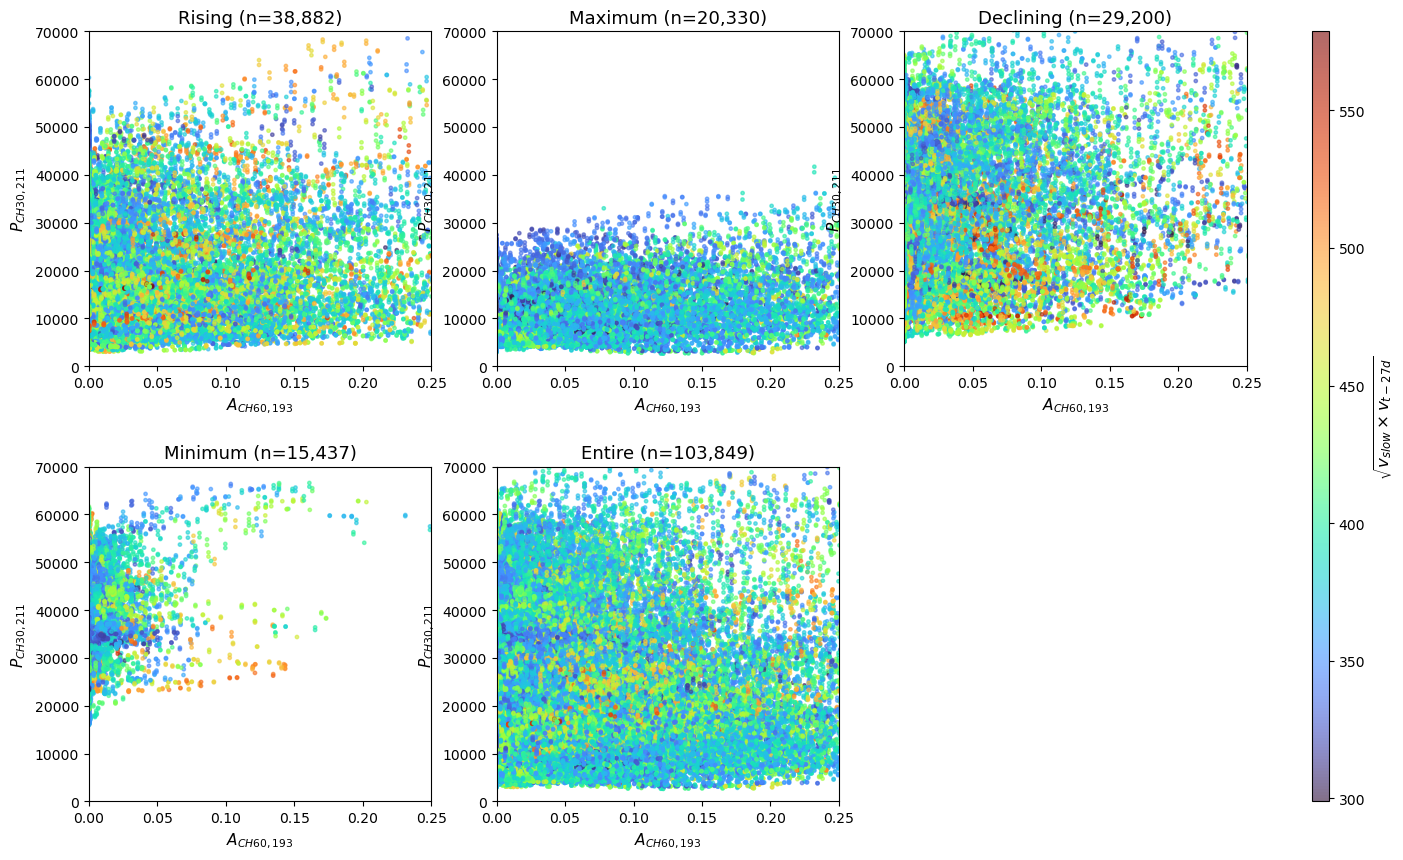

In [2]:
grid_scatter(
    x="A_CH60_193", y="P_CH30_211",
    color=lambda df: np.sqrt(V0 * df["speed_p27"].to_numpy()),
    xlabel=r"$A_{CH60,193}$", ylabel=r"$P_{CH30,211}$",
    cbar_label=r"$\sqrt{v_{slow} \times v_{t-27d}}$",
    xlim=(0, 0.25), ylim=(0, 70000), fit_on=None,
)
plt.show()

---

#### 2. $P_{CH}$ channel relationship: 193 Å vs 211 Å

$P_{CH30,193}$ vs $P_{CH30,211}$ (same timestamp), colored by solar wind speed, with a linear fit (on the Entire phase) showing how to convert between the two channels.

The SR-derived formula uses $P_{CH30,211}$; this relationship shows what the equivalent $P_{CH30,193}$ value would be, and how tight that relationship is.

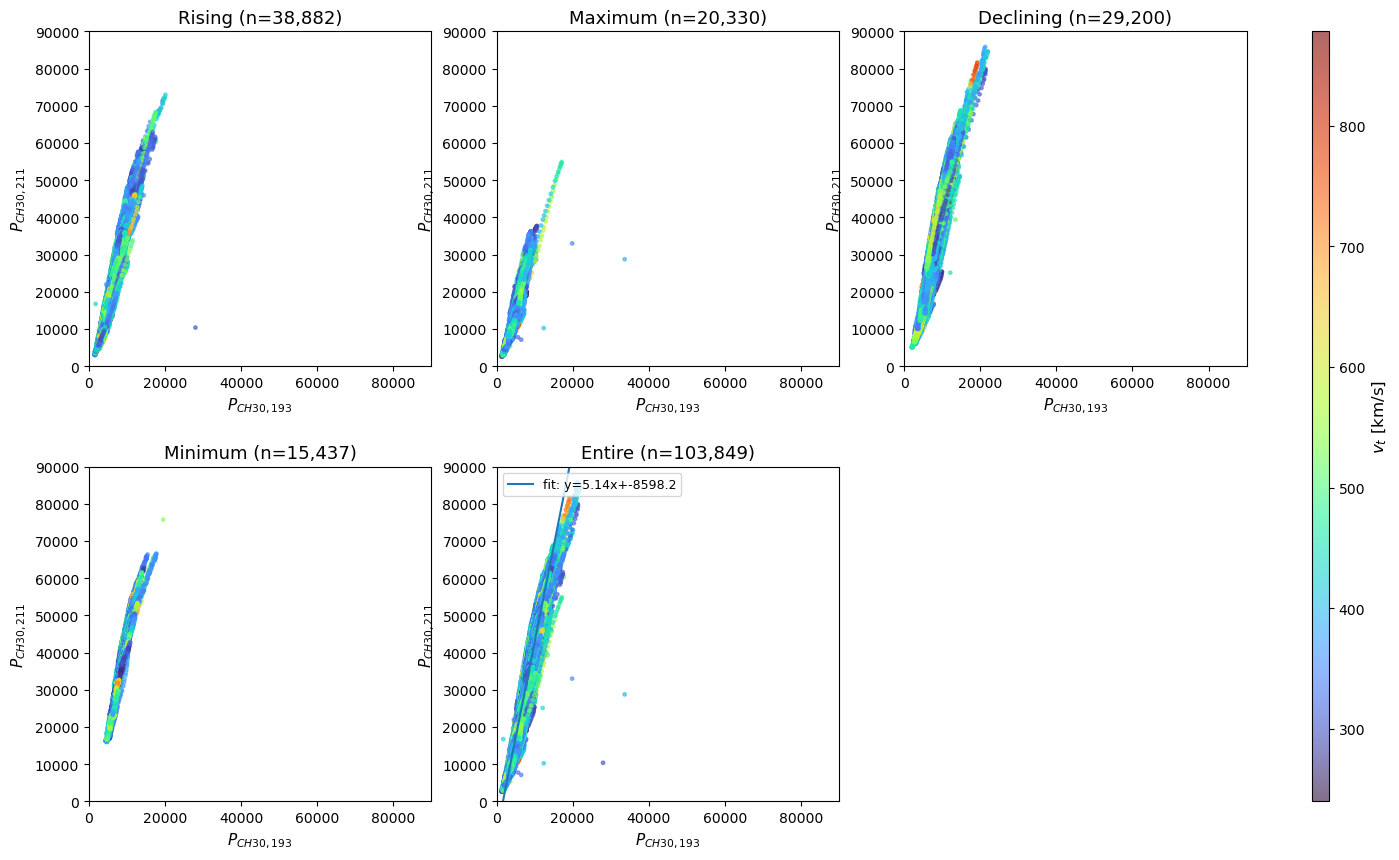

In [3]:
grid_scatter(
    x="P_CH30_193", y="P_CH30_211",
    color=lambda df: df["speed"].to_numpy(),
    xlabel=r"$P_{CH30,193}$", ylabel=r"$P_{CH30,211}$",
    cbar_label=r"$v_t$ [km/s]",
    xlim=(0, 90000), ylim=(0, 90000), fit_on="Entire",
)
plt.show()

---

#### 3. Predicted vs observed speed (published formula, fixed coefficients)

$v_{pred} = \sqrt{A_{CH60,193}^{t-4d} \times P_{CH30,211}^{t-4d}} + \sqrt{v_{t-27d} \times 372.1}$

This uses the paper's fixed-coefficient formula directly (no fitting) as a quick sanity check that it tracks observed speed. **This is illustrative only** — it is not the rigorous leave-one-group-out cross-validation used to actually select and evaluate the formula; see notebooks 05/06 for that.

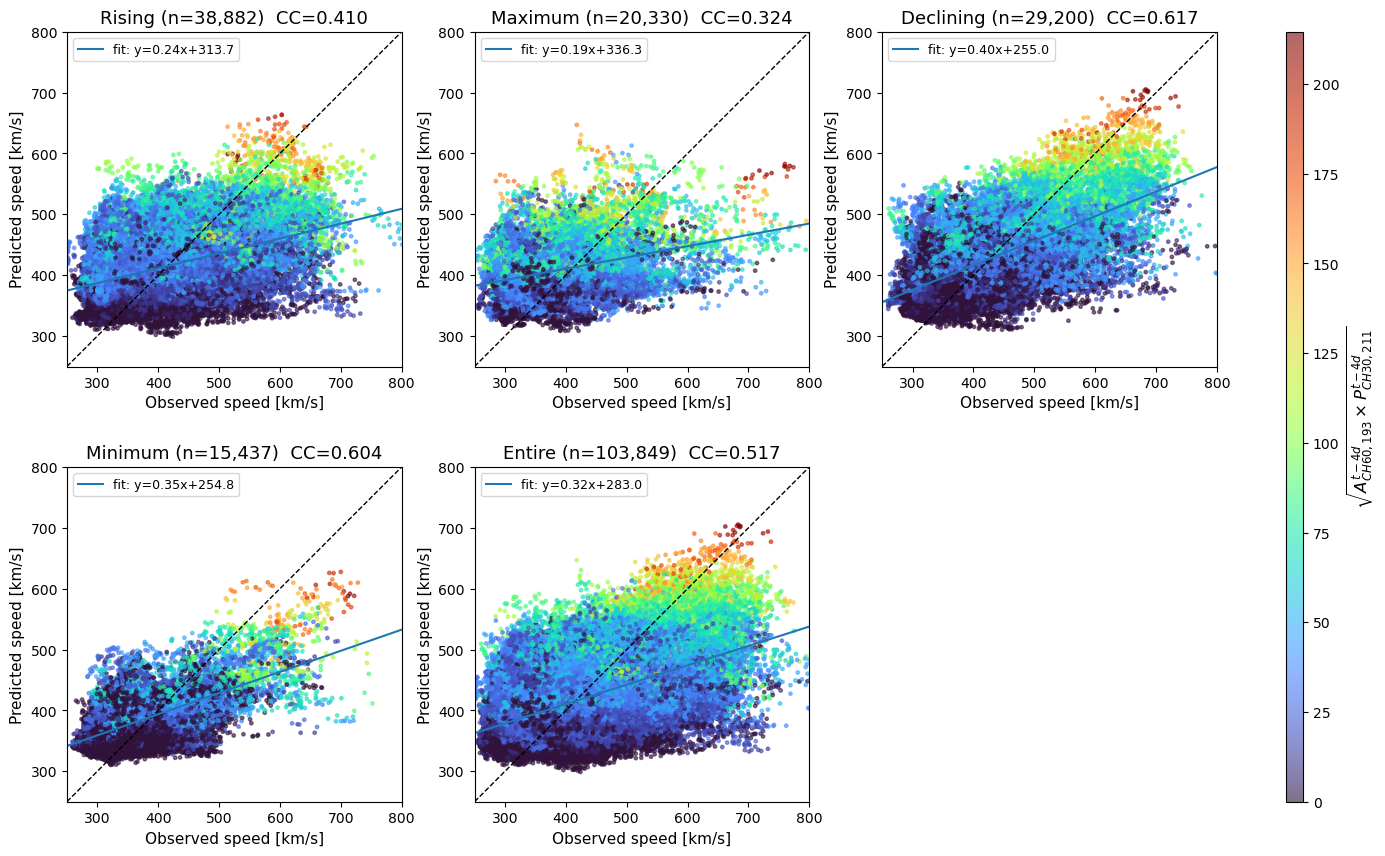

In [4]:
def predicted_speed(df):
    accel = np.sqrt(df["A_CH60_193_lag4"].to_numpy() * df["P_CH30_211_lag4"].to_numpy())
    background = np.sqrt(df["speed_p27"].to_numpy() * V0)
    return accel + background


grid_scatter(
    x="speed", y=predicted_speed,
    color=lambda df: np.sqrt(df["A_CH60_193_lag4"].to_numpy() * df["P_CH30_211_lag4"].to_numpy()),
    xlabel="Observed speed [km/s]", ylabel="Predicted speed [km/s]",
    cbar_label=r"$\sqrt{A_{CH60,193}^{t-4d} \times P_{CH30,211}^{t-4d}}$",
    xlim=(250, 800), ylim=(250, 800), fit_on=None, identity_line=True,
)
plt.show()